# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Adrian Hofman
* Username: ahhofman
* Student number: S6299113
* Group (AS1, etc.): ..........

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

<function matplotlib.pyplot.show(close=None, block=None)>

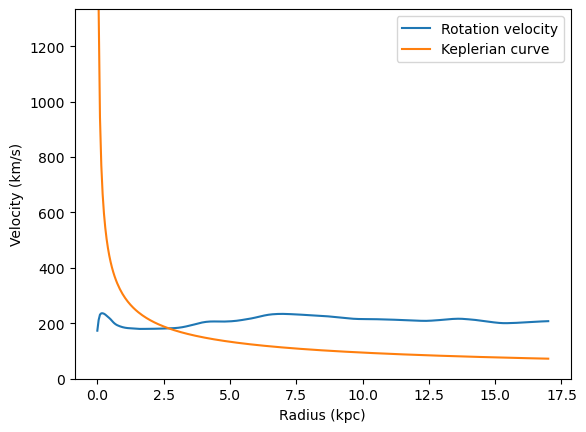

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.constants as scipy

# Loading the data
data = np.loadtxt('rotcur.dat', comments="#")

# Reading the columns
radius = data[:,0]; velocity = data[:,1]

# Creating a line plot
plt.plot(radius, velocity, label = 'Rotation velocity' )

# Calculating the Keplerian
M = 2*(10**10)*2*(10**30) # mass in kg
R1 = radius[1:] # radius without the 0 value
R = R1*(3*(10**19)) # radius in m
v = ((scipy.G*M/R)**(0.5))/1000 # velocity in km

# Creating a text file
np.savetxt('keplerian_curve.txt', v)

# Loading the text file and plotting it
keplerian_curve = np.loadtxt('keplerian_curve.txt')



plt.plot(R1, keplerian_curve, label = 'Keplerian curve')
plt.ylim(0, np.max(keplerian_curve))
plt.legend(loc='upper right')
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.show

# Observation: The Keplerian curve assumes a 1/r^2 dependency (as predicted by Kepler's law), which is the case for small radii (near the center of the galaxy), after that however, the velocity stops declining as rapidly and actually increases before becomeing somewhat constant

<div class="warning" style='background-color:#FFF2CF; color: #C16310; border-left: solid #EA9F27 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>⚠️</span> WARNING</b><br><br>
    Missing the observation <b>[0.5pt deducted from total points]</b>

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 3.5

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

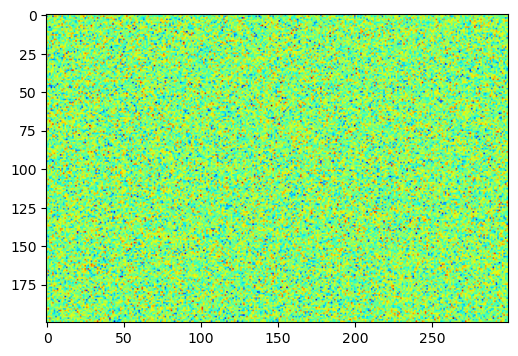

mean = 0.0215809504535478, std = 1.0223311732006113


<function matplotlib.pyplot.show(close=None, block=None)>

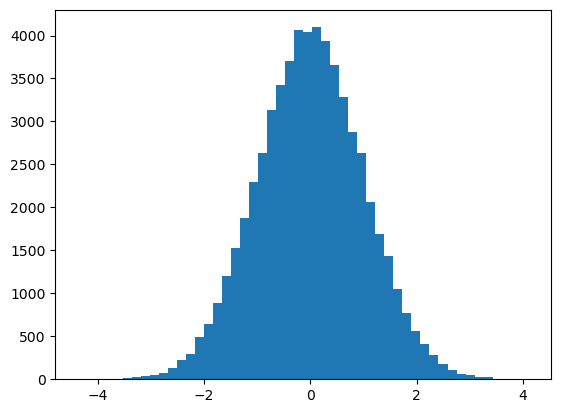

In [4]:
import numpy as np

# Making a 2D array
X = np.random.normal(loc=0.0, scale=1.0, size=200*300).reshape(200,300)

# Plot
plt.subplots(figsize=(8, 4))
plt.imshow(X, cmap = 'jet')
plt.show()

# Slicing the array
N = X[0:30,0:30]
mean = np.mean(N)
std = np.std(N)

print(f"mean = {mean}, std = {std}")

# The values are what i expected since the values were taken from a normal distribution with a mean 0 and std 1.

# Histogram

X_flat = X.flatten()

plt.hist(X_flat, bins = 50)
plt.show

# I recognise a normal distribution.

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 3

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

area = 18.84955592153876, perimeter = 15.865437575563961
center = (0, 0), semi major axis = 3.0, semi minor axis = 2.0, angle = 0


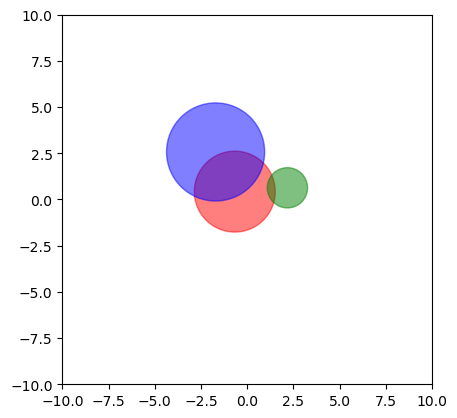

In [6]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import pi
import math

class AstroEllipse(Ellipse):
   def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
       assert(semi_major >= semi_minor)

       self.semi_major = semi_major
       self.semi_minor = semi_minor
       
       self.XY = (xc, yc)
       self.angle_mpl = position_angle 
       height = 2.0*semi_major
       width  = 2.0*semi_minor
       
       super().__init__(self.XY, width, height, angle=self.angle_mpl, **args)
   def area(self):  # method for calculating area
       area = pi * self.semi_major * self.semi_minor
       return area
       
   def perimeter(self): # method for calculating perimeter
       perimeter = pi*((3*(self.semi_major+self.semi_minor))-math.sqrt((3*self.semi_major+self.semi_minor)*(self.semi_major+3*self.semi_minor)))
       return perimeter

   def __str__(self):
       return f"center = {self.XY}, semi major axis = {self.semi_major}, semi minor axis = {self.semi_minor}, angle = {self.angle_mpl}"
       
# Example of an ellipse with a = 3, b = 2

ellipse = AstroEllipse(xc = 0, yc = 0, semi_major = 3.0, semi_minor = 2.0, position_angle = 0)
area = ellipse.area()
perimeter = ellipse.perimeter()
print(f"area = {area}, perimeter = {perimeter}")

# Method __str__

print(ellipse)

# Creating a class that defines a circle

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args): # xc, yc - the x and y coordinates of the center
        super().__init__(xc, yc, radius, radius, 0, **args)


# Plotting the three circles



fig, ax = plt.subplots()

xc1 = np.random.uniform(-5, 5)
yc1 = np.random.uniform(-5, 5)
r1 = np.random.uniform(1, 3)
circle1 = MyCircle(xc1, yc1, r1, color='red', alpha=0.5)
ax.add_patch(circle1)

xc2 = np.random.uniform(-5, 5)
yc2 = np.random.uniform(-5, 5)
r2 = np.random.uniform(1, 3)
circle2 = MyCircle(xc2, yc2, r2, color='blue', alpha=0.5)
ax.add_patch(circle2)

xc3 = np.random.uniform(-5, 5)
yc3 = np.random.uniform(-5, 5)
r3 = np.random.uniform(1, 3)
circle3 = MyCircle(xc3, yc3, r3, color='green', alpha=0.5)
ax.add_patch(circle3)

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")

plt.show()


In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

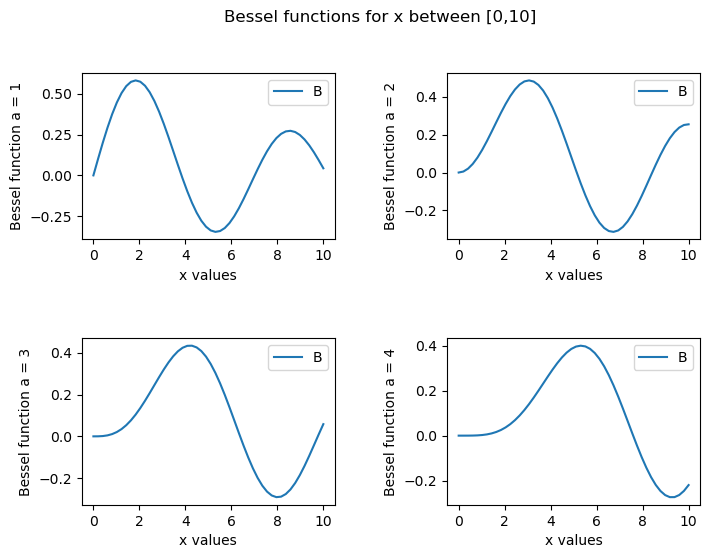

In [8]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt

# creating a class that calculates the Bessel functions

class Bessel:
    def __init__(self,a,x):
        self.a = a
        self.x = x
    def jv(self):
        return jv(self.a, self.x)

# Defining x and y values

x = np.linspace(0, 10, num = 50)
y1, y2, y3, y4 = Bessel(1, x), Bessel(2, x), Bessel(3, x), Bessel(4, x)

# Plotting 4 plots

fig = plt.figure(figsize = (8,6))
ax_array = fig.subplots(2, 2, squeeze = 'False')
fig.tight_layout(pad=5.0)

ax_array[0,0].plot(x, y1.jv())
ax_array[0,0].set_xlabel('x values')
ax_array[0,0].set_ylabel('Bessel function a = 1')
ax_array[0,0].legend('B')

ax_array[0,1].plot(x, y2.jv())
ax_array[0,1].set_xlabel('x values')
ax_array[0,1].set_ylabel('Bessel function a = 2')
ax_array[0,1].legend('B')

ax_array[1,0].plot(x, y3.jv())
ax_array[1,0].set_xlabel('x values')
ax_array[1,0].set_ylabel('Bessel function a = 3')
ax_array[1,0].legend('B')

ax_array[1,1].plot(x, y4.jv())
ax_array[1,1].set_xlabel('x values')
ax_array[1,1].set_ylabel('Bessel function a = 4')
ax_array[1,1].legend('B')

fig.suptitle('Bessel functions for x between [0,10]')
plt.savefig('bessel.png', transparent=True)

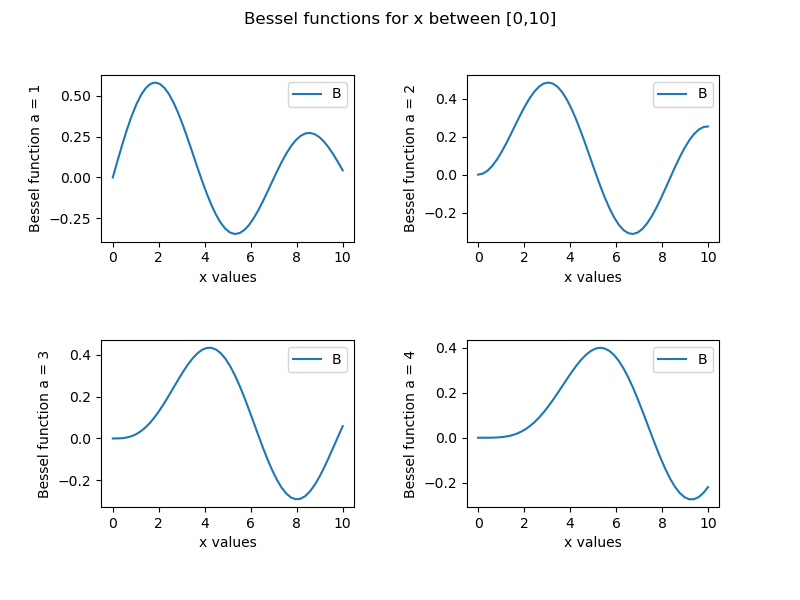

In [9]:
from IPython.display import Image, display

display(Image(filename='bessel.png'))

# for some reason my markdown wasnt accepting the command to show the image but here it is

<div class="warning" style='background-color:#FFF2CF; color: #C16310; border-left: solid #EA9F27 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>⚠️</span> WARNING</b><br><br>
    Missing saving the plot as a png and inserting the png into this notebook <b>[1pt deducted from total points]</b>

In [10]:
# Leave unaltered
totalpoints += 3
currentpoints += 2

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

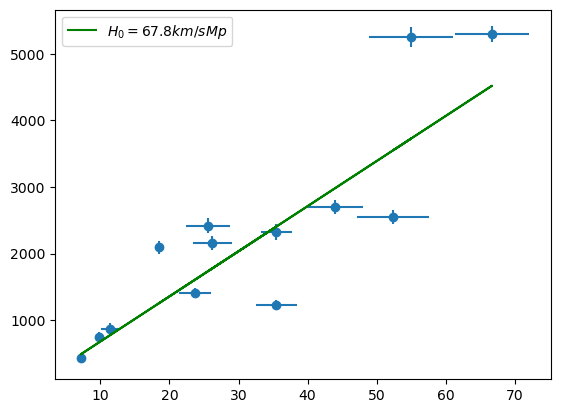

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure, show

data = np.array([
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ])
# Making the data into a 2d array

newdata = data.reshape(13,4)

# Using slicing syntax to separate data into distance and velocity

d = newdata[:,0]
v = newdata[:,1]
error_d = newdata[:,2]
error_v = newdata[:,3]

# Plotting the graph

fig = plt.figure()
ax = fig.subplots()
ax.scatter(d,v)
ax.errorbar(d,v,error_v, error_d, fmt = 'None')
ax.plot(d, 67.8*d, label = r'$H_0 = 67.8 km/sMp$', color = 'green')
ax.legend()

<div class="warning" style='background-color:#FFF2CF; color: #C16310; border-left: solid #EA9F27 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>⚠️</span> WARNING</b><br><br>
    We want you to import figure and show (Do not forget about this one when plotting, cause ipynb does it for you) from matplotlib.pyplot <b>[1pt deducted from total points]</b><br>
    You did not include the H0 value in the legend <b>[0.5pt deducted]</b>

In [12]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.5

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 15.0.  Task Grade = 8.3
